In [6]:
# import libraries
import os
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [7]:
# load the dataset

path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
data_dir = os.path.join(path, "PetImages")

print("Dataset classes:", os.listdir(data_dir))




Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Dataset classes: ['Dog', 'Cat']


In [8]:
import os
import shutil
from PIL import Image, UnidentifiedImageError

src_dir = data_dir  # your original /kaggle/input/... path
dst_dir = "/tmp/PetImages"  # writable location

bad_images = []
copied = 0

for category in os.listdir(src_dir):
    src_folder = os.path.join(src_dir, category)
    dst_folder = os.path.join(dst_dir, category)

    if not os.path.isdir(src_folder):
        continue

    os.makedirs(dst_folder, exist_ok=True)

    for file in os.listdir(src_folder):
        src_path = os.path.join(src_folder, file)

        try:
            with Image.open(src_path) as img:
                img.verify()
            with Image.open(src_path) as img:
                img.load()

            # Only copy if image is valid
            shutil.copy2(src_path, os.path.join(dst_folder, file))
            copied += 1

        except (UnidentifiedImageError, OSError, Exception):
            print(f"Skipped bad image: {src_path}")
            bad_images.append(src_path)

print(f"\nBad images skipped: {len(bad_images)}")
print(f"Clean images copied: {copied}")
print("Cleaning complete.")

# Update data_dir to point to clean copy
data_dir = dst_dir
print(f"\ndata_dir is now: {data_dir}")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Skipped bad image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg
Skipped bad image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/Thumbs.db
Skipped bad image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/Thumbs.db
Skipped bad image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg

Bad images skipped: 4
Clean images copied: 24998
Cleaning complete.

data_dir is now: /tmp/PetImages


In [ ]:
#normalize images to train and validate split

ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print("Class labels:", train_gen.class_indices)




In [13]:
# build cnn model

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

#Stop training early
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

#Reduce learning rate iif platue (not improving)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=1,
    min_lr=1e-6,
    verbose=1
)





Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:

# train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)



Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7912 - loss: 0.4517 - val_accuracy: 0.8017 - val_loss: 0.4407
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8255 - loss: 0.3839 - val_accuracy: 0.8161 - val_loss: 0.3981
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8642 - loss: 0.3164 - val_accuracy: 0.8191 - val_loss: 0.4011
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9010 - loss: 0.2376 - val_accuracy: 0.8235 - val_loss: 0.4120
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9412 - loss: 0.1507 - val_accuracy: 0.8237 - val_loss: 0.4817
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9651 - loss: 0.0967 - val_accuracy: 0.8211 - val_loss: 0.6199
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9765 - loss: 0.0636 - val_accuracy: 0.8211 - val_loss: 0.6254
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9878 - loss: 0.0386 - 

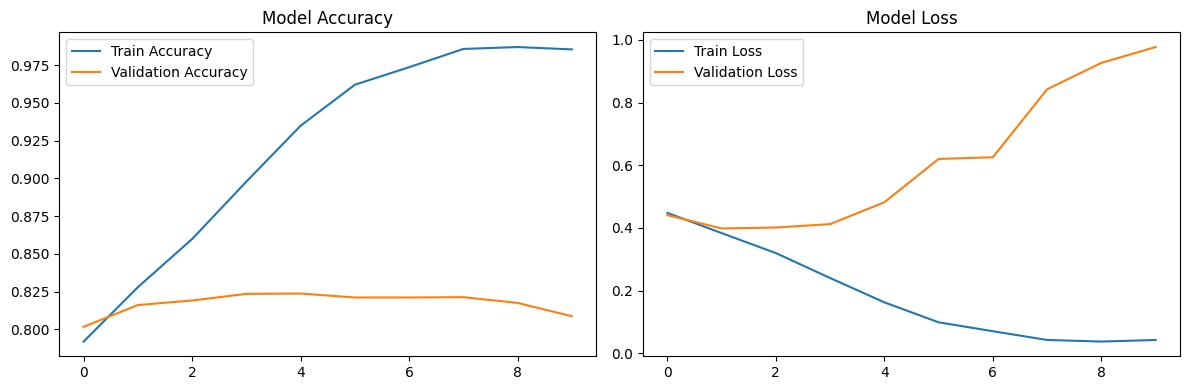

In [16]:


# 6 Plot Training Results

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(12,4))


# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title("Model Accuracy")
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title("Model Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:

# 7 Predictions

val_gen.reset()

y_pred = (model.predict(val_gen) > 0.5).astype(int).flatten()
y_true = val_gen.classes

# Evaluation metrics
print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=['Cat','Dog']))

print("\nFinal Metrics")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))




157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step

Classification Report
              precision    recall  f1-score   support

         Cat       0.49      0.47      0.48      2499
         Dog       0.49      0.52      0.51      2499

    accuracy                           0.49      4998
   macro avg       0.49      0.49      0.49      4998
weighted avg       0.49      0.49      0.49      4998


Final Metrics
Accuracy : 0.49379751900760305
Precision: 0.49410422213769495
Recall   : 0.5198079231692677
F1 Score : 0.5066302652106084
